# Task
Fetch stock data for a user-specified Taiwanese stock ticker for the past 10 years and save it to a CSV file.

## 安裝必要的套件

### Subtask:
安裝用於股票資料抓取的 `yfinance` 套件。


**Reasoning**:
The subtask requires installing the `yfinance` package, so I will use `pip` to install it.



In [1]:
pip install yfinance


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 匯入所需套件

### Subtask:
匯入 `yfinance` 和 `pandas` 套件，以便進行資料抓取與處理。


**Reasoning**:
The subtask requires importing `yfinance` and `pandas` packages. I will create a code block to import these packages, aliasing `pandas` as `pd`.



In [2]:
import yfinance as yf
import pandas as pd
print("yfinance and pandas packages imported successfully.")

yfinance and pandas packages imported successfully.


In [3]:
import os

SEED = 2026
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import random
import numpy as np
import tensorflow as tf

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

print(f"All random seeds set to {SEED}")


I0000 00:00:1775891570.207208 2092896 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All random seeds set to 2026


## 定義抓取股票資料的函數

### Subtask:
建立一個函數，輸入股票代碼，抓取近十年的每日收盤價、最高價、最低價等資訊。


**Reasoning**:
The subtask requires defining a function to fetch stock data for the past 10 years. I will create a Python function `fetch_stock_data` that takes a ticker as input, calculates the start and end dates, uses `yfinance` to download the historical data, and returns a pandas DataFrame.



In [ ]:
from datetime import datetime, timedelta

def fetch_stock_data(ticker):
    """
    Fetches historical stock data for a given ticker for the past 10 years.

    Args:
        ticker (str): The stock ticker symbol (e.g., '2330.TW' for TSMC).

    Returns:
        pandas.DataFrame: Historical stock data including Open, High, Low, Close, Volume, etc.
                          Returns an empty DataFrame if data fetching fails.
    """
    end_date = datetime.now() + timedelta(days=1)
    # end_date = pd.to_datetime("2026-04-02") + timedelta(days=1)
    start_date = end_date - timedelta(days=10*365) # Approximate 10 years

    try:
        stock = yf.Ticker(ticker)
        # Fetch daily data for the specified period
        data = stock.history(start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), interval='1d')
        if data.empty:
            print(f"No data found for {ticker} in the last 10 years.")
        else:
            print(f"Successfully fetched data for {ticker} from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}.")
        return data
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return pd.DataFrame() # Return an empty DataFrame on error

print("fetch_stock_data function defined.")

fetch_stock_data function defined.


## 讓使用者輸入股票代碼

### Subtask:
提示使用者輸入要查詢的台灣股票代碼。


**Reasoning**:
The subtask requires prompting the user for a Taiwanese stock ticker and reminding them about the '.TW' suffix. I will use the `input()` function to get the ticker from the user and store it in a variable.



In [5]:
# @title
# ticker_symbol = input("請輸入要查詢的台灣股票代碼 (例如 '2330.TW'，請務必加上 '.TW' 後綴): ")
ticker_symbol = "2330.TW"  # 例如：2330.TW
print(f"您輸入的股票代碼是: {ticker_symbol}")

您輸入的股票代碼是: 2330.TW


In [6]:
stock_data = fetch_stock_data(ticker_symbol)

if not stock_data.empty:
    filename = f"{ticker_symbol.replace('.TW', '')}_stock_data.csv"
    stock_data.to_csv(filename, index=True) # index=True to save the Date as a column
    print(f"股票資料已成功儲存為 {filename}")
else:
    print(f"無法為 {ticker_symbol} 抓取到股票資料，因此沒有檔案儲存。")

Successfully fetched data for 2330.TW from 2016-04-05 to 2026-04-03.
股票資料已成功儲存為 2330_stock_data.csv


In [7]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Load the data into a DataFrame and set "Date" as index
file_path = filename
stock_df = pd.read_csv(file_path, index_col="Date", parse_dates=True)
print(f"Data loaded from {file_path}. First 5 rows:\n{stock_df.head()}\n")

# 2. Compute MA5 and drop the first 4 NaN rows
stock_df["MA5"] = stock_df["Close"].rolling(5).mean()
stock_df = stock_df.dropna(subset=["MA5"])
print(f"Rows after dropping MA5 NaN: {len(stock_df)}")

# 3. Extract features
close_prices  = stock_df["Close"].values.reshape(-1, 1)
volume_prices = stock_df["Volume"].values.reshape(-1, 1)
ma5_prices    = stock_df["MA5"].values.reshape(-1, 1)
print(f"Close shape: {close_prices.shape}, Volume shape: {volume_prices.shape}, MA5 shape: {ma5_prices.shape}\n")

# 4. Separate MinMaxScaler for each feature
scaler_close  = MinMaxScaler(feature_range=(0, 1))
scaler_volume = MinMaxScaler(feature_range=(0, 1))
scaler_ma5    = MinMaxScaler(feature_range=(0, 1))

# 5. Fit & transform each feature independently
scaled_close_prices  = scaler_close.fit_transform(close_prices)    # (N, 1)
scaled_volume_prices = scaler_volume.fit_transform(volume_prices)  # (N, 1)
scaled_ma5_prices    = scaler_ma5.fit_transform(ma5_prices)        # (N, 1)

# Alias: scaler_close is used for inverse_transform on predictions
scaler = scaler_close

print("Close  normalized:", scaled_close_prices[:3].flatten())
print("Volume normalized:", scaled_volume_prices[:3].flatten())
print("MA5    normalized:", scaled_ma5_prices[:3].flatten())

# 6. Combine into a 3-feature matrix: [Close, Volume, MA5]
scaled_features = np.hstack([scaled_close_prices, scaled_volume_prices, scaled_ma5_prices])  # (N, 3)
print(f"\nCombined feature matrix shape: {scaled_features.shape}")

# 7. Define look_back variable
look_back = 90
print(f"look_back period defined as: {look_back}")

Data loaded from 2330_stock_data.csv. First 5 rows:
                                 Open        High         Low       Close  \
Date                                                                        
2016-04-06 00:00:00+08:00  117.655435  118.033748  116.142181  116.142181   
2016-04-07 00:00:00+08:00  117.277102  117.277102  115.385536  116.898788   
2016-04-08 00:00:00+08:00  116.520500  119.547007  116.520500  119.168694   
2016-04-11 00:00:00+08:00  118.033712  120.303591  117.655399  119.925278   
2016-04-12 00:00:00+08:00  119.168651  120.681904  119.168651  119.925278   

                             Volume  Dividends  Stock Splits  
Date                                                          
2016-04-06 00:00:00+08:00  58134000        0.0           0.0  
2016-04-07 00:00:00+08:00  35238000        0.0           0.0  
2016-04-08 00:00:00+08:00  41032000        0.0           0.0  
2016-04-11 00:00:00+08:00  21758000        0.0           0.0  
2016-04-12 00:00:00+08:00  148

In [8]:
def create_dataset(dataset, look_back=1):
    """
    dataset : 2-D array (N, n_features). Target y is always column 0 (Close).
    Returns X shape (samples, look_back, n_features) and y shape (samples,).
    """
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back), :])  # all features
        dataY.append(dataset[i + look_back, 0])       # target = Close (col 0)
    return np.array(dataX), np.array(dataY)

# Create X (look_back steps of [Close, Volume]) and y (next-day Close)
X, y = create_dataset(scaled_features, look_back)
print(f"X shape: {X.shape}")  # (samples, look_back, 2)
print(f"y shape: {y.shape}")  # (samples,)
# X is already 3-D: no further reshape needed


X shape: (2336, 90, 3)
y shape: (2336,)


## Split Data into Training and Testing Sets

### Subtask:
Divide the preprocessed `X` (features) and `y` (labels) datasets into distinct training and testing sets.


**Reasoning**:
The subtask requires splitting the `X` and `y` datasets into training and testing sets while preserving temporal order. I will use `sklearn.model_selection.train_test_split` with `test_size=0.2` and `shuffle=False`.



In [9]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (95% train, 5% test)
# shuffle=False is crucial to maintain the temporal order of the time series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, shuffle=False)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2219, 90, 3)
X_test shape: (117, 90, 3)
y_train shape: (2219,)
y_test shape: (117,)


## Define LSTM Model with Attention Mechanism

### Subtask:
Design a new Keras/TensorFlow Sequential model that integrates an Attention layer with the existing LSTM layers. This will allow the model to dynamically weight different parts of the input sequence, potentially improving prediction accuracy.


**Reasoning**:
The subtask requires designing a new Keras/TensorFlow Sequential model with an Attention layer. I will start by defining the custom Attention layer class as specified in the instructions, and then build the sequential model incorporating this custom layer along with LSTM and Dense layers.



In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Layer, Dropout
import tensorflow.keras.backend as K
import tensorflow as tf

# 1. Define a custom Attention layer class
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], input_shape[-1]),
                               initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[-1],),
                               initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # x is the input from the previous layer (LSTM with return_sequences=True)
        # Calculate attention scores
        # ui = tanh(xW + b)
        ui = K.tanh(K.dot(x, self.W) + self.b)

        # Context vector (usually a learnable parameter or a fixed vector of ones)
        # For simplicity, we can use a vector of ones here. A more complex attention
        # might involve another dense layer to calculate the context vector u_w.
        uw = K.ones_like(ui[:, :, 0]) # Create a vector of ones with the same time steps
        # Reshape for broadcasting
        uw = K.expand_dims(uw)

        # Alpha = softmax(ui * uw)
        alpha = K.softmax(K.sum(ui * uw, axis=2))
        alpha = K.expand_dims(alpha)

        # Context vector z = sum(alpha * x)
        context_vector = K.sum(x * alpha, axis=1)
        return context_vector

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

# 2. Initialize a Sequential model
model_with_attention = Sequential()

# 3. Add an Input layer
model_with_attention.add(Input(shape=(look_back, 3)))

# 4. Add an LSTM layer with return_sequences=True for the Attention layer
model_with_attention.add(LSTM(units=128, return_sequences=True))
model_with_attention.add(LSTM(units=64, return_sequences=True))

# 5. Add the custom Attention layer
model_with_attention.add(Attention())

# 6. Add a Dense output layer
model_with_attention.add(Dense(units=1))

# Compile the model (optional, but good practice to show it's a complete model)
model_with_attention.compile(optimizer='adam', loss='mean_squared_error')

# 7. Print the model summary
print("LSTM model with Attention layer defined and compiled.")
model_with_attention.summary()

I0000 00:00:1775891574.530138 2092896 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38484 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:01:00.0, compute capability: 8.0


LSTM model with Attention layer defined and compiled.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 128)        │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 90, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,217 (473.50 KB)

 Trainable params: 121,217 (473.50 KB)

 Non-trainable params: 0 (0.00 B)

## Train Attention-LSTM Model

### Subtask:
Train the Attention-LSTM model using the prepared training data (`X_train`, `y_train`). Monitor the loss during training to ensure convergence.


**Reasoning**:
I will train the `model_with_attention` using the `X_train` and `y_train` datasets, as well as the specified epochs and batch size, to fit the model to the training data.



In [11]:
print("Starting Attention-LSTM model training...")
history_attention = model_with_attention.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    verbose=1
)
print("Attention-LSTM model training completed.")


Starting Attention-LSTM model training...
Epoch 1/50


E0000 00:00:1775891576.389718 2092896 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1775891578.527858 2093896 cuda_dnn.cc:461] Loaded cuDNN version 91002


70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0038
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.9665e-04
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.8329e-04
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.3144e-04
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.7964e-04
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.4121e-04
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2677e-04
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4616e-04
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.5856e-04
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.3421e-04
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.9679e-04
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.8268e-04
Epoch 13/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.6227e-04
Epoch 14/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5676e-04
Epoch 15/50
70/70 ━━━━━━━━━━━━

## Make Predictions with Attention-LSTM Model

### Subtask:
Use the trained Attention-LSTM model to make predictions on both the training data (`X_train`) and the unseen test data (`X_test`).


**Reasoning**:
The subtask requires making predictions on both training and testing data using the trained Attention-LSTM model. I will use the `model_with_attention.predict()` method for `X_train` and `X_test`, and then print their shapes to confirm the output dimensions.



In [12]:
print("Generating predictions using Attention-LSTM model...")

# 1. Generate predictions for the training dataset
train_predict_attention = model_with_attention.predict(X_train)

# 2. Generate predictions for the testing dataset
test_predict_attention = model_with_attention.predict(X_test)

# 3. Print the shapes of the prediction arrays
print(f"Shape of train_predict_attention: {train_predict_attention.shape}")
print(f"Shape of test_predict_attention: {test_predict_attention.shape}")

print("Predictions generated successfully.")

Generating predictions using Attention-LSTM model...


 1/70 ━━━━━━━━━━━━━━━━━━━━ 15s 227ms/step

E0000 00:00:1775891630.642123 2092896 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Shape of train_predict_attention: (2219, 1)
Shape of test_predict_attention: (117, 1)
Predictions generated successfully.


## Inverse Transform Predictions and Actual Values

### Subtask:
Convert both the predicted values and the actual values (for both training and testing sets) back to their original stock price scale using the `scaler` object. This is necessary for meaningful interpretation and evaluation.


**Reasoning**:
The subtask requires inverse transforming the predicted and actual values for both training and testing sets to their original scale using the `scaler` object. I will apply `scaler.inverse_transform()` to each array, ensuring `y_train` and `y_test` are reshaped correctly before transformation, and then print the shapes.



In [13]:
print("Inverse transforming predictions and actual values...")

# 1. Inverse transform train_predict_attention
train_predict_attention = scaler.inverse_transform(train_predict_attention)

# 2. Inverse transform test_predict_attention
test_predict_attention = scaler.inverse_transform(test_predict_attention)

# 3. Inverse transform y_train (reshape before transforming)
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))

# 4. Inverse transform y_test (reshape before transforming)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# 5. Print the shapes of the inverse-transformed arrays
print(f"Shape of inverse transformed train_predict_attention: {train_predict_attention.shape}")
print(f"Shape of inverse transformed test_predict_attention: {test_predict_attention.shape}")
print(f"Shape of inverse transformed y_train_inverse: {y_train_inverse.shape}")
print(f"Shape of inverse transformed y_test_inverse: {y_test_inverse.shape}")

print("Inverse transformation completed.")

Inverse transforming predictions and actual values...
Shape of inverse transformed train_predict_attention: (2219, 1)
Shape of inverse transformed test_predict_attention: (117, 1)
Shape of inverse transformed y_train_inverse: (2219, 1)
Shape of inverse transformed y_test_inverse: (117, 1)
Inverse transformation completed.


## Visualize Attention-LSTM Predictions

### Subtask:
Create a visualization (e.g., a line plot) comparing the inverse-transformed predicted stock prices against the actual stock prices for both the training and testing sets. This will help assess the model's performance and generalization. Ensure to include legends for clarity.


**Reasoning**:
The subtask requires visualizing the Attention-LSTM model's predictions against actual values for both training and testing sets to assess performance. I will generate a code block to create a line plot using `matplotlib.pyplot`, plotting the inverse-transformed actual and predicted values for both sets with proper labels, title, and legends.



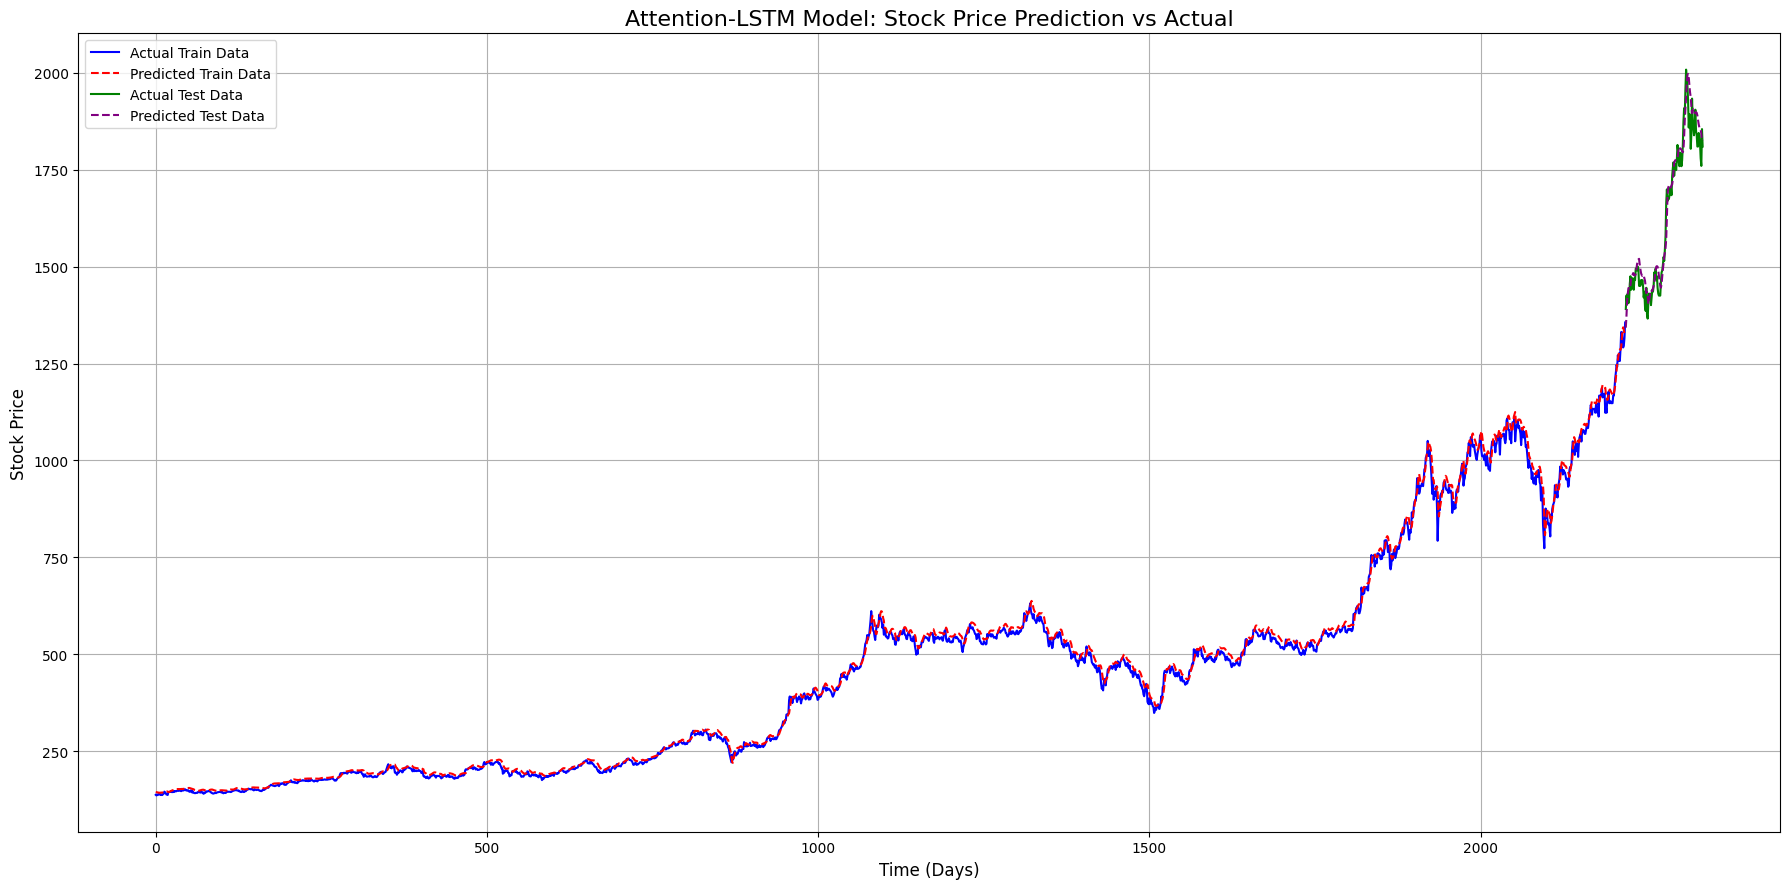

Visualization of Attention-LSTM predictions complete.


In [14]:
import matplotlib.pyplot as plt

# Create a figure and an axes object for the plot
fig, ax = plt.subplots(figsize=(18, 9))

# Plot Actual Train Data
ax.plot(y_train_inverse, label='Actual Train Data', color='blue', linewidth=1.5)

# Plot Predicted Train Data
ax.plot(train_predict_attention, label='Predicted Train Data', color='red', linestyle='--', linewidth=1.5)

# Create an index for the test data that starts after the training data
test_data_indices = range(len(y_train_inverse), len(y_train_inverse) + len(y_test_inverse))

# Plot Actual Test Data
ax.plot(test_data_indices, y_test_inverse, label='Actual Test Data', color='green', linewidth=1.5)

# Plot Predicted Test Data
ax.plot(test_data_indices, test_predict_attention, label='Predicted Test Data', color='purple', linestyle='--', linewidth=1.5)

# Add title and labels
ax.set_title('Attention-LSTM Model: Stock Price Prediction vs Actual', fontsize=16)
ax.set_xlabel('Time (Days)', fontsize=12)
ax.set_ylabel('Stock Price', fontsize=12)

# Add legend
ax.legend(loc='upper left', fontsize=10)

# Add grid
ax.grid(True)

# Display the plot
plt.tight_layout()
plt.show()
print("Visualization of Attention-LSTM predictions complete.")

## Evaluate Attention-LSTM Model Performance

### Subtask:
Calculate and report evaluation metrics, such as Root Mean Squared Error (RMSE), for both the training and testing predictions to quantitatively assess the performance of the Attention-LSTM model. This will provide a clear measure of accuracy.


The Root Mean Squared Error (RMSE) is a commonly used metric to measure the difference between values predicted by a model and the values observed. In the context of stock price prediction, RMSE quantifies the average magnitude of the errors made by the model in predicting stock prices. A lower RMSE value indicates a better fit of the model to the data. It is particularly useful because it gives a relatively high weight to large errors, meaning it is sensitive to outliers. The RMSE values for both the training and testing sets will indicate how well the Attention-LSTM model learned from the historical data and how well it generalizes to unseen data, respectively.

**Reasoning**:
Now that the explanation for RMSE has been provided, I will print the already calculated `train_rmse` and `test_rmse` values to report the evaluation metrics as required by the subtask.



In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    # Avoid division by zero by replacing 0 actual values with a small epsilon or handling them
    # Here we'll just ignore cases where y_true is 0, which might not be ideal for all scenarios
    # For stock prices, 0 is unlikely, but good to be aware.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Filter out zero values in y_true to prevent division by zero
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Or raise an error if no non-zero actual values

    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# Calculate RMSE for training data
train_rmse = np.sqrt(mean_squared_error(y_train_inverse, train_predict_attention))

# Calculate MAE for training data
train_mae = mean_absolute_error(y_train_inverse, train_predict_attention)

# Calculate MAPE for training data
train_mape = mean_absolute_percentage_error(y_train_inverse, train_predict_attention)

# Calculate RMSE for testing data
test_rmse = np.sqrt(mean_squared_error(y_test_inverse, test_predict_attention))

# Calculate MAE for testing data
test_mae = mean_absolute_error(y_test_inverse, test_predict_attention)

# Calculate MAPE for testing data
test_mape = mean_absolute_percentage_error(y_test_inverse, test_predict_attention)

print("Attention-LSTM Model Performance Metrics:")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print(f"Train MAPE: {train_mape:.2f}%")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")

Attention-LSTM Model Performance Metrics:
Train RMSE: 15.4880
Train MAE: 11.1348
Train MAPE: 2.68%
Test RMSE: 42.1936
Test MAE: 33.1688
Test MAPE: 2.02%


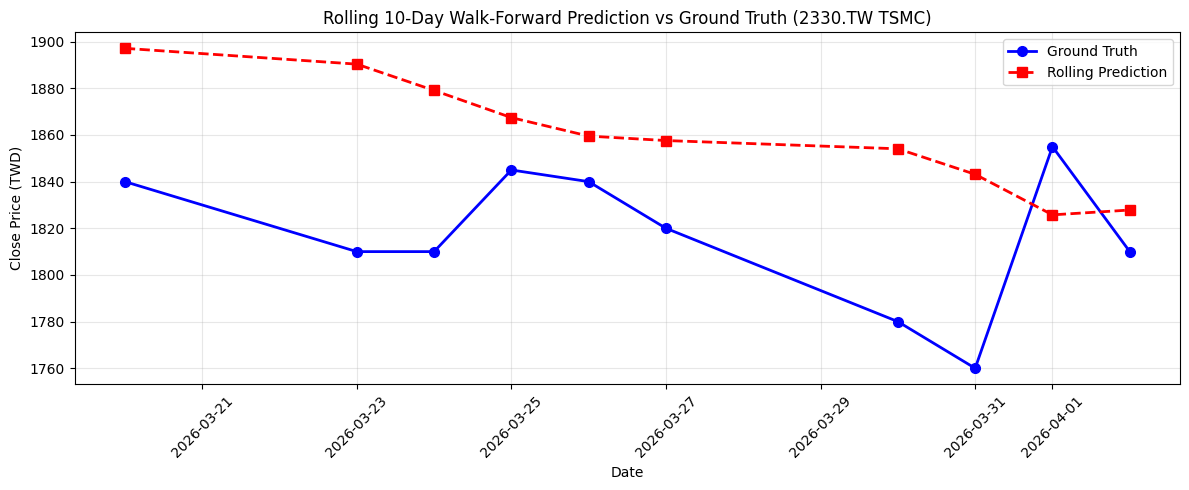

Date            Ground Truth   Prediction      Error   Error%
--------------------------------------------------------------
2026-03-20           1840.00      1897.15     +57.15   +3.11%
2026-03-23           1810.00      1890.37     +80.37   +4.44%
2026-03-24           1810.00      1879.09     +69.09   +3.82%
2026-03-25           1845.00      1867.45     +22.45   +1.22%
2026-03-26           1840.00      1859.52     +19.52   +1.06%
2026-03-27           1820.00      1857.61     +37.61   +2.07%
2026-03-30           1780.00      1854.08     +74.08   +4.16%
2026-03-31           1760.00      1843.14     +83.14   +4.72%
2026-04-01           1855.00      1825.76     -29.24   -1.58%
2026-04-02           1810.00      1827.83     +17.83   +0.99%


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ── Rolling 10-Day Walk-Forward Prediction vs Ground Truth ──
n_days = 10

# Use last 10 test input windows directly (each window contains 100-day history)
rolling_preds_scaled = model_with_attention.predict(X_test[-n_days:], verbose=0)
rolling_preds = scaler.inverse_transform(rolling_preds_scaled).flatten()

# Ground truth for the same period (already inverse-transformed)
rolling_gt = y_test_inverse[-n_days:].flatten()

# Corresponding dates in stock_df
train_size = X_train.shape[0]
last_10_dates = [stock_df.index[look_back + train_size + i]
                 for i in range(len(X_test) - n_days, len(X_test))]

# ── Plot ──
plt.figure(figsize=(12, 5))
plt.plot(last_10_dates, rolling_gt,    "b-o", label="Ground Truth",        linewidth=2, markersize=7)
plt.plot(last_10_dates, rolling_preds, "r--s", label="Rolling Prediction",  linewidth=2, markersize=7)
plt.title("Rolling 10-Day Walk-Forward Prediction vs Ground Truth (2330.TW TSMC)")
plt.xlabel("Date")
plt.ylabel("Close Price (TWD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── Comparison table ──
print(f"{"Date":<14} {"Ground Truth":>13} {"Prediction":>12} {"Error":>10} {"Error%":>8}")
print("-" * 62)
for i, date in enumerate(last_10_dates):
    err     = rolling_preds[i] - rolling_gt[i]
    err_pct = err / rolling_gt[i] * 100
    print(f"{str(date.date()):<14} {rolling_gt[i]:>13.2f} {rolling_preds[i]:>12.2f} {err:>+10.2f} {err_pct:>+7.2f}%")


In [17]:
import pandas as pd
import numpy as np

# ── Predict Next Trading Day Stock Price (Close + Volume + MA5) ──
last_close_seq  = scaled_close_prices[-look_back:]   # (look_back, 1)
last_volume_seq = scaled_volume_prices[-look_back:]  # (look_back, 1)
last_ma5_seq    = scaled_ma5_prices[-look_back:]     # (look_back, 1)
last_sequence   = np.hstack([last_close_seq, last_volume_seq, last_ma5_seq]).reshape(1, look_back, 3)

next_pred_scaled = model_with_attention.predict(last_sequence, verbose=0)
next_pred_price  = scaler_close.inverse_transform(next_pred_scaled)[0, 0]

last_date       = stock_df.index[-1]
next_trade_date = last_date + pd.tseries.offsets.BDay(1)

last_close  = stock_df["Close"].iloc[-1]
change      = next_pred_price - last_close
change_pct  = change / last_close * 100

print("=" * 50)
print("  Next Trading Day Stock Price Prediction")
print("=" * 50)
print(f"  Stock      : 2330.TW (TSMC)")
print(f"  Last date  : {last_date.date()}  |  Close: {last_close:.2f} TWD")
print(f"  Next date  : {next_trade_date.date()}")
print(f"  Predicted  : {next_pred_price:.2f} TWD")
print(f"  Change     : {change:+.2f} TWD  ({change_pct:+.2f}%)")
print("=" * 50)

  Next Trading Day Stock Price Prediction
  Stock      : 2330.TW (TSMC)
  Last date  : 2026-04-02  |  Close: 1810.00 TWD
  Next date  : 2026-04-03
  Predicted  : 1832.25 TWD
  Change     : +22.25 TWD  (+1.23%)
